In [57]:
import pandas as pd

df = pd.read_csv('study_logs_20260506_200056.csv')
df.head()

,id,user_id,group_name,event_type,event_time,payload
0,44,1,G1,page_duration,2026-03-16T21:33:26.659126+00:00,"{""page"": ""ethics"", ""event"": ""page_duration"", ""..."
1,45,1,G1,page_duration,2026-03-16T21:35:32.363304+00:00,"{""page"": ""unknown"", ""event"": ""page_duration"", ..."
2,46,1,G1,page_duration,2026-03-17T00:42:23.877946+00:00,"{""page"": ""unknown"", ""event"": ""page_duration"", ..."
3,47,1,G1,page_duration,2026-03-17T00:42:23.915613+00:00,"{""page"": ""ethics"", ""event"": ""page_duration"", ""..."
4,48,1,G1,page_duration,2026-03-17T00:43:29.569630+00:00,"{""page"": ""pre_assessment"", ""event"": ""page_dura..."


In [58]:
questionnaire = df[df['event_type'] == 'questionnaire_completed']

grouped = {name: group.reset_index(drop=True) for name, group in questionnaire.groupby('group_name')}

study_log_g1 = grouped.get('G1')
study_log_g2 = grouped.get('G2')

study_log_g1.to_csv('study_log_g1.csv', index=False)
study_log_g2.to_csv('study_log_g2.csv', index=False)

print(f"G1: {len(study_log_g1)} responses → study_log_g1.csv")
print(f"G2: {len(study_log_g2)} responses → study_log_g2.csv")

G1: 43 responses → study_log_g1.csv
G2: 41 responses → study_log_g2.csv


In [59]:
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Parse payload into responses + demographics for each group
def parse_group(csv_path):
    df = pd.read_csv(csv_path)
    records = []
    for _, row in df.iterrows():
        p = json.loads(row['payload'])
        record = {'user_id': row['user_id']}
        record.update(p.get('responses', {}))
        record.update(p.get('demographics', {}))
        records.append(record)
    return pd.DataFrame(records)

g1 = parse_group('study_log_g1.csv')
g2 = parse_group('study_log_g2.csv')

print(f"G1: {len(g1)} participants | G2: {len(g2)} participants")

G1: 43 participants | G2: 41 participants


## 1 · Demographics
*Are the two groups comparable?*

  ✓ saved → figures/fig1_demographics.png


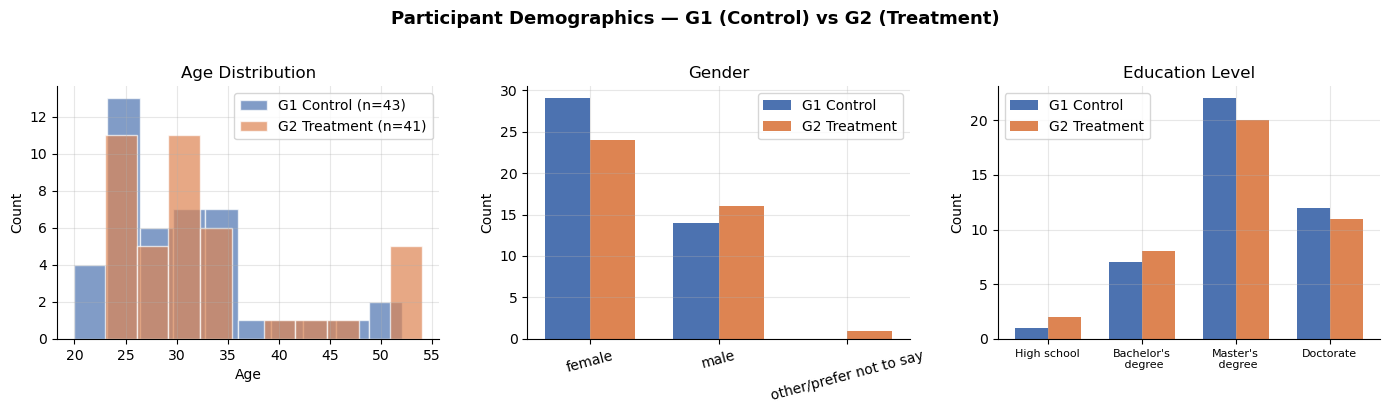

In [60]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Participant Demographics — G1 (Control) vs G2 (Treatment)',
             fontsize=13, fontweight='bold', y=1.02)

# Age distribution
ax = axes[0]
ax.hist(g1['age'], bins=10, color=C1, alpha=0.7, label=f'G1 Control (n={len(g1)})', edgecolor='white')
ax.hist(g2['age'], bins=10, color=C2, alpha=0.7, label=f'G2 Treatment (n={len(g2)})', edgecolor='white')
ax.set_title('Age Distribution')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()

# Gender
ax = axes[1]
cats = sorted(set(g1['gender'].dropna().unique()) | set(g2['gender'].dropna().unique()))
x = np.arange(len(cats))
w = 0.35
ax.bar(x - w/2, [g1['gender'].value_counts().get(c, 0) for c in cats], w, color=C1, label='G1 Control')
ax.bar(x + w/2, [g2['gender'].value_counts().get(c, 0) for c in cats], w, color=C2, label='G2 Treatment')
ax.set_xticks(x); ax.set_xticklabels(cats, rotation=15)
ax.set_title('Gender'); ax.set_ylabel('Count'); ax.legend()

# Education
ax = axes[2]
edu_order = ["High school", "Bachelor's degree", "Master's degree", "Doctorate"]
x = np.arange(len(edu_order))
ax.bar(x - w/2, [g1['education'].value_counts().get(c, 0) for c in edu_order], w, color=C1, label='G1 Control')
ax.bar(x + w/2, [g2['education'].value_counts().get(c, 0) for c in edu_order], w, color=C2, label='G2 Treatment')
ax.set_xticks(x); ax.set_xticklabels([e.replace("'s", "'s\n") for e in edu_order], fontsize=8)
ax.set_title('Education Level'); ax.set_ylabel('Count'); ax.legend()

plt.tight_layout()
save_fig('fig1_demographics')
plt.show()


## 2 · Primary Outcomes — Violin + Box plots
*The three constructs the study was designed to measure: trust, recommendation usefulness, and behavioural intent.*

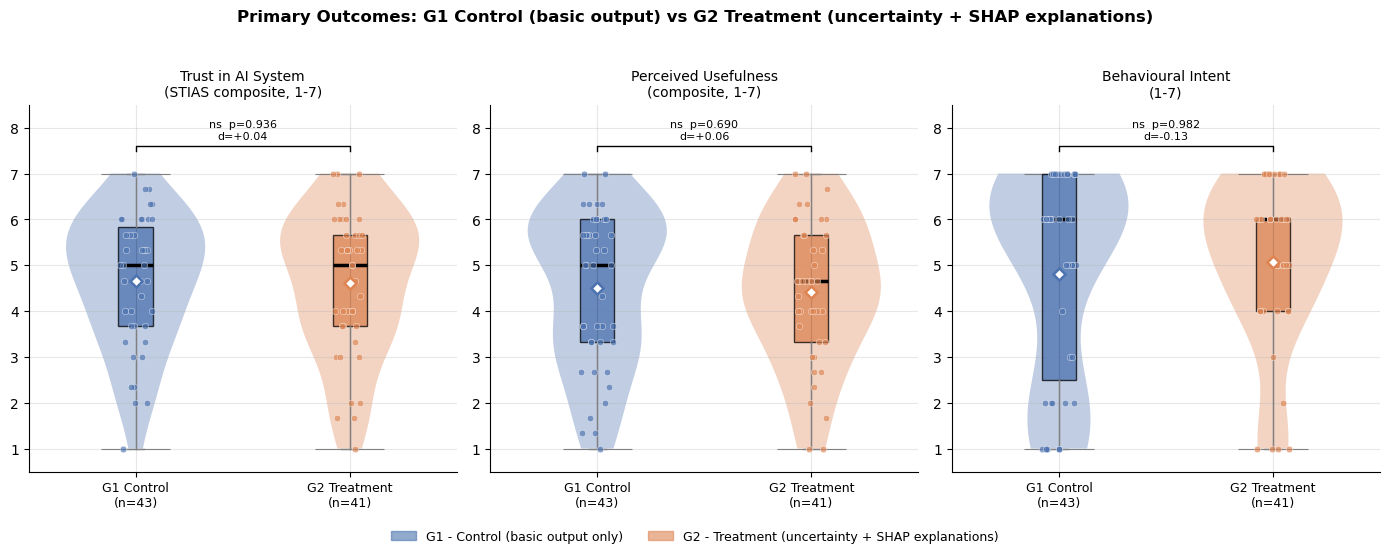

In [61]:
# Composite scores
g1['trust_score']  = g1[['q_stias_trust','q_stias_reliable','q_stias_understandable']].mean(axis=1)
g2['trust_score']  = g2[['q_stias_trust','q_stias_reliable','q_stias_understandable']].mean(axis=1)
g1['useful_score'] = g1[['q_ai_reasonable','q_ai_trust_recs','q_ai_recs_useful']].mean(axis=1)
g2['useful_score'] = g2[['q_ai_reasonable','q_ai_trust_recs','q_ai_recs_useful']].mean(axis=1)

outcomes = [
    ('trust_score',              'Trust in AI System\n(STIAS composite, 1-7)'),
    ('useful_score',             'Perceived Usefulness\n(composite, 1-7)'),
    ('q_intent_stress_technique','Behavioural Intent\n(1-7)'),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(
    'Primary Outcomes: G1 Control (basic output) vs G2 Treatment (uncertainty + SHAP explanations)',
    fontsize=12, fontweight='bold', y=1.03
)

rng = np.random.default_rng(42)
for ax, (col, label) in zip(axes, outcomes):
    a, b = g1[col].dropna(), g2[col].dropna()
    p, d = mwu_cohend(a, b)

    parts = ax.violinplot([a, b], positions=[1, 2], showmedians=False, widths=0.65)
    for pc, color in zip(parts['bodies'], [C1, C2]):
        pc.set_facecolor(color); pc.set_alpha(0.35)
    for key in ['cbars', 'cmins', 'cmaxes']:
        parts[key].set_color('gray'); parts[key].set_linewidth(0.8)

    bp = ax.boxplot([a, b], positions=[1, 2], widths=0.16, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2.5),
                    whiskerprops=dict(color='gray', linewidth=1),
                    capprops=dict(color='gray', linewidth=1),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))
    bp['boxes'][0].set_facecolor(C1); bp['boxes'][0].set_alpha(0.75)
    bp['boxes'][1].set_facecolor(C2); bp['boxes'][1].set_alpha(0.75)

    for vals, pos, color in [(a, 1, C1), (b, 2, C2)]:
        jitter = rng.uniform(-0.08, 0.08, len(vals))
        ax.scatter(pos + jitter, vals, color=color, s=22, alpha=0.65, zorder=4,
                   edgecolors='white', linewidths=0.4)

    ax.plot(1, a.mean(), marker='D', color='white', markersize=6, zorder=5,
            markeredgecolor=C1, markeredgewidth=1.8)
    ax.plot(2, b.mean(), marker='D', color='white', markersize=6, zorder=5,
            markeredgecolor=C2, markeredgewidth=1.8)

    y_top = max(a.max(), b.max()) + 0.5
    ax.plot([1, 1, 2, 2], [y_top, y_top+0.1, y_top+0.1, y_top], color='black', lw=1)
    stars = sig_stars(p)
    ax.text(1.5, y_top + 0.25, f'{stars}  p={p:.3f}\nd={d:+.2f}', ha='center', fontsize=8)

    ax.set_xticks([1, 2])
    ax.set_xticklabels([f'G1 Control\n(n={len(a)})', f'G2 Treatment\n(n={len(b)})'], fontsize=9)
    ax.set_title(label, fontsize=10)
    ax.set_ylim(0.5, y_top + 1.0)

p1 = mpatches.Patch(color=C1, alpha=0.6, label='G1 - Control (basic output only)')
p2 = mpatches.Patch(color=C2, alpha=0.6, label='G2 - Treatment (uncertainty + SHAP explanations)')
fig.legend(handles=[p1, p2], loc='lower center', ncol=2, fontsize=9,
           bbox_to_anchor=(0.5, -0.06), frameon=False)
plt.tight_layout()
plt.savefig('figures/fig2_primary_outcomes.png', dpi=150, bbox_inches='tight')
plt.show()

In [62]:
# Primary outcome statistics: means, Cohen's d, Mann-Whitney U p-value
rows = []
for col, label in [
    ('trust_score',               'Trust (STIAS composite)'),
    ('useful_score',              'Perceived Usefulness'),
    ('q_intent_stress_technique', 'Behavioural Intent'),
]:
    a, b = g1[col].dropna(), g2[col].dropna()
    p, d = mwu_cohend(a, b)
    rows.append({
        'Outcome':     label,
        'G1 mean':     round(a.mean(), 2),
        'G1 SD':       round(a.std(ddof=1), 2),
        'G2 mean':     round(b.mean(), 2),
        'G2 SD':       round(b.std(ddof=1), 2),
        'Δ (G1−G2)':  round(a.mean() - b.mean(), 2),
        "Cohen's d":   round(d, 2),
        'p (MWU)':     round(p, 3),
    })

stats_df = pd.DataFrame(rows).set_index('Outcome')
display(stats_df)

,G1 mean,G1 SD,G2 mean,G2 SD,Δ (G1−G2),Cohen's d,p (MWU)
Outcome,,,,,,,
Trust (STIAS composite),4.67,1.44,4.61,1.57,0.06,0.04,0.936
Perceived Usefulness,4.50,1.69,4.41,1.57,0.10,0.06,0.690
Behavioural Intent,4.81,2.23,5.07,1.81,-0.26,-0.13,0.982


## 2b · STIAS Items — Non-aggregated
*Each of the three trust subscale items shown individually to reveal whether effects are uniform across dimensions.*

  ✓ saved → figures/fig2b_stias_items.png


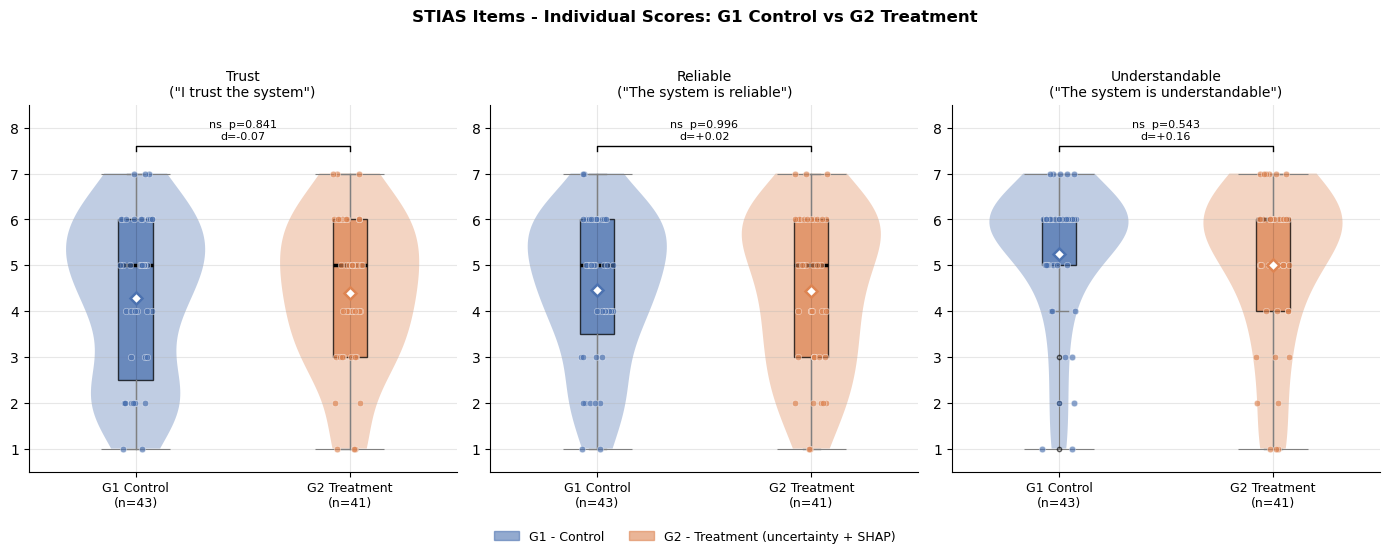

,G1 mean,G1 SD,G2 mean,G2 SD,Δ (G1−G2),Cohen's d,p (MWU)
Item,,,,,,,
"Trust (""I trust the system"")",4.28,1.76,4.39,1.64,-0.11,-0.07,0.841
"Reliable (""The system is reliable"")",4.47,1.61,4.44,1.72,0.03,0.02,0.996
"Understandable (""The system is understandable"")",5.26,1.54,5.00,1.75,0.26,0.16,0.543


In [63]:
stias_items = [
    ('q_stias_trust',          'Trust\n("I trust the system")'),
    ('q_stias_reliable',       'Reliable\n("The system is reliable")'),
    ('q_stias_understandable', 'Understandable\n("The system is understandable")'),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(
    'STIAS Items - Individual Scores: G1 Control vs G2 Treatment',
    fontsize=12, fontweight='bold', y=1.03
)

rng = np.random.default_rng(42)
item_stats = []

for ax, (col, label) in zip(axes, stias_items):
    a, b = g1[col].dropna(), g2[col].dropna()
    p, d = mwu_cohend(a, b)
    item_stats.append({'Item': label.replace('\n', ' '), 'G1 mean': round(a.mean(), 2),
                       'G1 SD': round(a.std(ddof=1), 2), 'G2 mean': round(b.mean(), 2),
                       'G2 SD': round(b.std(ddof=1), 2), 'Δ (G1−G2)': round(a.mean()-b.mean(), 2),
                       "Cohen's d": round(d, 2), 'p (MWU)': round(p, 3)})

    parts = ax.violinplot([a, b], positions=[1, 2], showmedians=False, widths=0.65)
    for pc, color in zip(parts['bodies'], [C1, C2]):
        pc.set_facecolor(color); pc.set_alpha(VIOLIN_ALPHA)
    for key in ['cbars', 'cmins', 'cmaxes']:
        parts[key].set_color('gray'); parts[key].set_linewidth(0.8)

    bp = ax.boxplot([a, b], positions=[1, 2], widths=0.16, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2.5),
                    whiskerprops=dict(color='gray', linewidth=1),
                    capprops=dict(color='gray', linewidth=1),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))
    bp['boxes'][0].set_facecolor(C1); bp['boxes'][0].set_alpha(0.75)
    bp['boxes'][1].set_facecolor(C2); bp['boxes'][1].set_alpha(0.75)

    for vals, pos, color in [(a, 1, C1), (b, 2, C2)]:
        jitter = rng.uniform(-0.08, 0.08, len(vals))
        ax.scatter(pos + jitter, vals, color=color, s=22, alpha=SCATTER_ALPHA, zorder=4,
                   edgecolors='white', linewidths=0.4)

    ax.plot(1, a.mean(), marker='D', color='white', markersize=6, zorder=5,
            markeredgecolor=C1, markeredgewidth=1.8)
    ax.plot(2, b.mean(), marker='D', color='white', markersize=6, zorder=5,
            markeredgecolor=C2, markeredgewidth=1.8)

    y_top = max(a.max(), b.max()) + 0.5
    ax.plot([1, 1, 2, 2], [y_top, y_top+0.1, y_top+0.1, y_top], color='black', lw=1)
    stars = sig_stars(p)
    ax.text(1.5, y_top + 0.25, f'{stars}  p={p:.3f}\nd={d:+.2f}', ha='center', fontsize=8)

    ax.set_xticks([1, 2])
    ax.set_xticklabels([f'G1 Control\n(n={len(a)})', f'G2 Treatment\n(n={len(b)})'], fontsize=9)
    ax.set_title(label, fontsize=10)
    ax.set_ylim(0.5, y_top + 1.0)

p1 = mpatches.Patch(color=C1, alpha=0.6, label='G1 - Control')
p2 = mpatches.Patch(color=C2, alpha=0.6, label='G2 - Treatment (uncertainty + SHAP)')
fig.legend(handles=[p1, p2], loc='lower center', ncol=2, fontsize=9,
           bbox_to_anchor=(0.5, -0.06), frameon=False)
plt.tight_layout()
save_fig('fig2b_stias_items')
plt.show()

display(pd.DataFrame(item_stats).set_index('Item'))

## 3 · Effect Size Summary — All Scale Items
*How large is the G1 vs G2 difference on every measured item?*

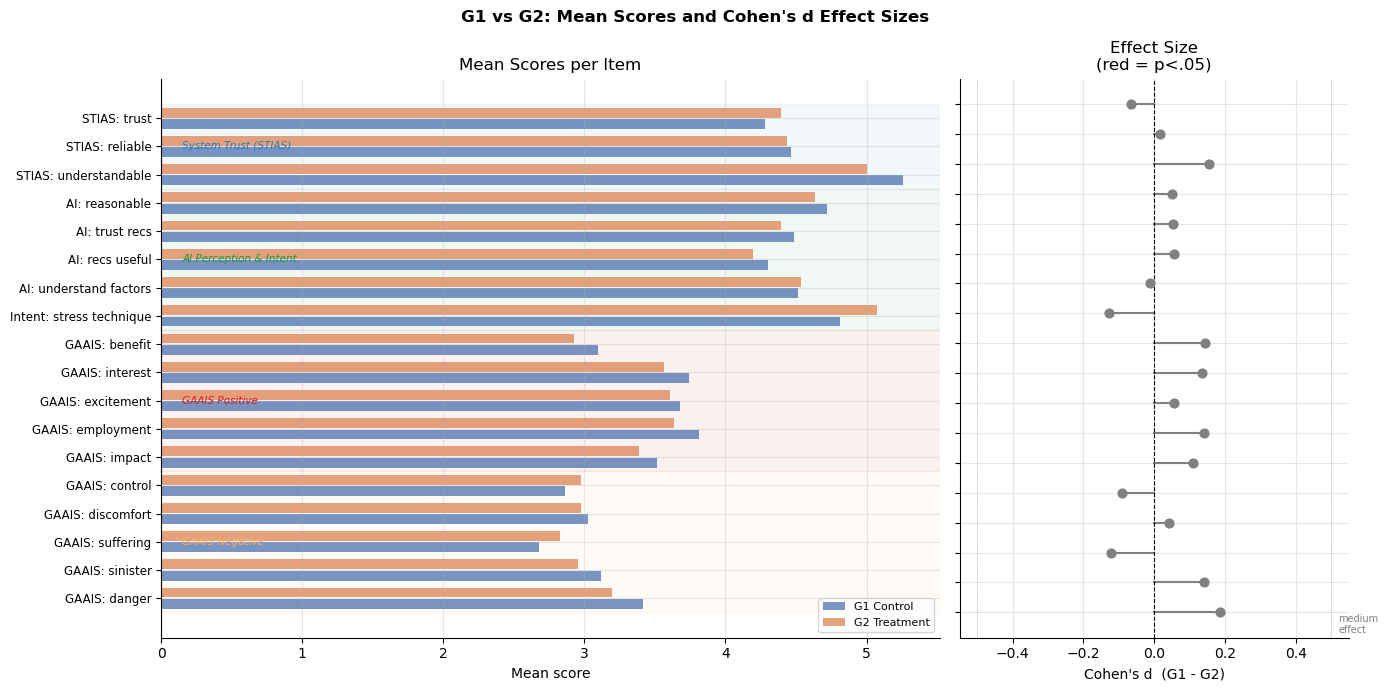

In [64]:
all_cols = [
    'q_stias_trust','q_stias_reliable','q_stias_understandable',
    'q_ai_reasonable','q_ai_trust_recs','q_ai_recs_useful','q_ai_understand_factors',
    'q_intent_stress_technique',
    'q_gaais_benefit','q_gaais_interest','q_gaais_excitement','q_gaais_employment','q_gaais_impact',
    'q_gaais_control','q_gaais_discomfort','q_gaais_suffering','q_gaais_sinister','q_gaais_danger',
]
labels = [
    'STIAS: trust','STIAS: reliable','STIAS: understandable',
    'AI: reasonable','AI: trust recs','AI: recs useful','AI: understand factors',
    'Intent: stress technique',
    'GAAIS: benefit','GAAIS: interest','GAAIS: excitement','GAAIS: employment','GAAIS: impact',
    'GAAIS: control','GAAIS: discomfort','GAAIS: suffering','GAAIS: sinister','GAAIS: danger',
]
sections = [
    (0,  3,  '#2c7bb6', 'System Trust (STIAS)'),
    (3,  8,  '#1a9641', 'AI Perception & Intent'),
    (8,  13, '#d7191c', 'GAAIS Positive'),
    (13, 18, '#fdae61', 'GAAIS Negative'),
]

ds, ps, means1, means2 = [], [], [], []
for col in all_cols:
    a, b = g1[col].dropna(), g2[col].dropna()
    p, d = mwu_cohend(a, b)
    ds.append(d); ps.append(p)
    means1.append(a.mean()); means2.append(b.mean())

y = np.arange(len(all_cols))
fig, axes = plt.subplots(1, 2, figsize=(14, 7), gridspec_kw={'width_ratios': [2, 1]})
fig.suptitle("G1 vs G2: Mean Scores and Cohen's d Effect Sizes",
             fontsize=12, fontweight='bold')

# Left: mean comparison
ax = axes[0]
ax.barh(y + 0.2, means1, 0.35, color=C1, alpha=0.75, label='G1 Control')
ax.barh(y - 0.2, means2, 0.35, color=C2, alpha=0.75, label='G2 Treatment')
for start, end, color, name in sections:
    ax.axhspan(start - 0.5, end - 0.5, color=color, alpha=0.06, zorder=0)
    ax.text(0.15, (start + end) / 2 - 0.5, name, fontsize=7.5,
            color=color, va='center', fontstyle='italic')
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=8.5)
ax.set_xlabel('Mean score')
ax.set_title('Mean Scores per Item')
ax.legend(loc='lower right', fontsize=8)
ax.invert_yaxis()

# Right: Cohen's d lollipop
ax2 = axes[1]
colors = ['#c0392b' if p < .05 else 'gray' for p in ps]
for i, (d_val, color) in enumerate(zip(ds, colors)):
    ax2.plot([0, d_val], [i, i], color=color, lw=1.5)
    ax2.scatter(d_val, i, color=color, s=40, zorder=3)
ax2.axvline(0, color='black', lw=0.8, ls='--')
ax2.axvline( 0.5, color='gray', lw=0.5, ls=':')
ax2.axvline(-0.5, color='gray', lw=0.5, ls=':')
ax2.set_yticks(y)
ax2.set_yticklabels([])
ax2.set_xlabel("Cohen's d  (G1 - G2)")
ax2.set_title("Effect Size\n(red = p<.05)")
ax2.invert_yaxis()
ax2.text(0.52, len(all_cols)-0.3, 'medium\neffect', fontsize=7, color='gray')

plt.tight_layout()
plt.savefig('figures/fig3_effect_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 · Engagement Proxy: Attention Check
*Which feature did participants identify as most influential in the AI output?*

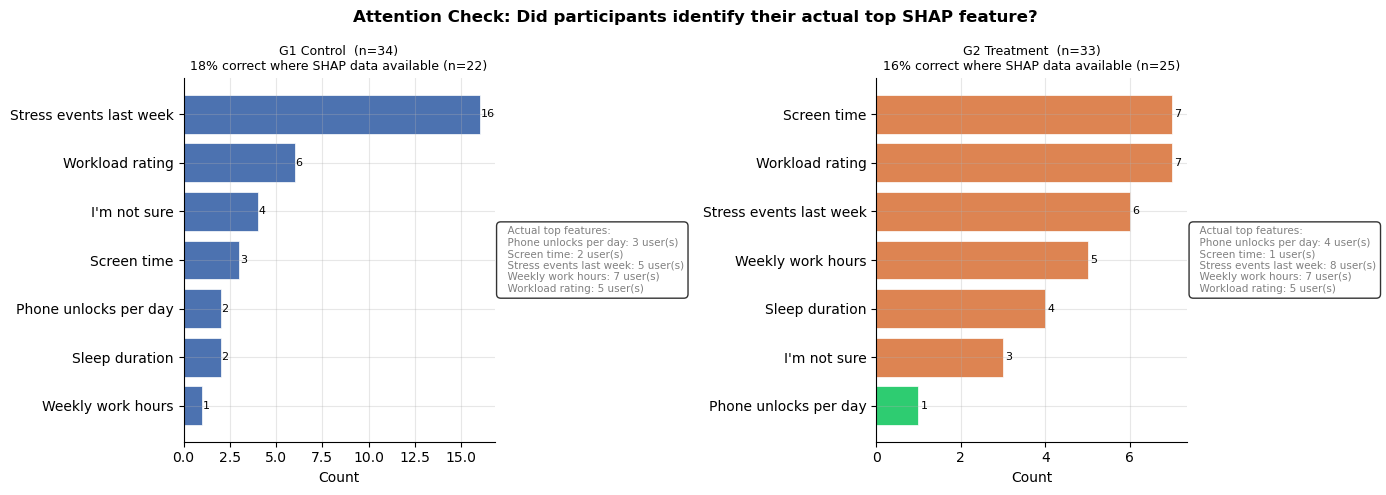


Per-user detail:


,user_id,group,answered,actual_top,correct
0,1,G1,Stress events last week,Weekly work hours,False
1,3,G1,Stress events last week,None,None
2,5,G1,Workload rating,None,None
3,7,G1,Weekly work hours,Stress events last week,False
4,9,G1,Stress events last week,Weekly work hours,False
...,...,...,...,...,...
62,58,G2,I'm not sure,Phone unlocks per day,False
63,60,G2,Stress events last week,Stress events last week,True
64,62,G2,Screen time,Weekly work hours,False
65,64,G2,Workload rating,Stress events last week,False


In [66]:
# ── Attention check: per-user correct answer from actual SHAP drivers ────────
df_raw = pd.read_csv('study_logs_20260506_200056.csv')

feature_map = {
    'stress_event_count_last_week': 'Stress events last week',
    'work_hours_per_week':          'Weekly work hours',
    'workload_rating':              'Workload rating',
    'sleep_duration_hr':            'Sleep duration',
    'screen_time_hr':               'Screen time',
    'screen_unlocks_per_day':       'Phone unlocks per day',
    'job_satisfaction':             'Job satisfaction',
    'sleep_quality_rating':         'Sleep quality',
    'social_interactions_count':    'Social interactions',
    'physical_activity_frequency':  'Physical activity',
}

# Last prediction per user (what was actually shown)
preds = (df_raw[df_raw['event_type'] == 'prediction_requested']
         .sort_values('event_time')
         .groupby('user_id').last()
         .reset_index())
top_features = {}
for _, row in preds.iterrows():
    p = json.loads(row['payload'])
    drivers = p.get('prediction', {}).get('drivers', [])
    if drivers:
        feat, _ = max(drivers, key=lambda x: abs(x[1]))
        top_features[row['user_id']] = feature_map.get(feat, feat)

# Last questionnaire per user
quest = (df_raw[df_raw['event_type'] == 'questionnaire_completed']
         .sort_values('event_time')
         .groupby('user_id').last()
         .reset_index())

records = []
for _, row in quest.iterrows():
    uid = row['user_id']
    p = json.loads(row['payload'])
    answered = p.get('responses', {}).get('q_attention_check_feature')
    actual   = top_features.get(uid)          # None if no prediction log
    correct  = (answered == actual) if actual else None
    records.append({'user_id': uid, 'group': row['group_name'],
                    'answered': answered, 'actual_top': actual, 'correct': correct})

attn = pd.DataFrame(records)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Attention Check: Did participants identify their actual top SHAP feature?',
             fontsize=12, fontweight='bold')

for ax, group_id, color in [(axes[0], 'G1', C1), (axes[1], 'G2', C2)]:
    sub = attn[attn['group'] == group_id]
    has_data = sub[sub['actual_top'].notna()]
    pct = has_data['correct'].mean() * 100 if len(has_data) else 0
    n_total, n_assessed = len(sub), len(has_data)

    # Build bar data: for assessed users, colour by correct/wrong;
    # separate row for 'No prediction log'
    answer_counts = sub['answered'].value_counts()
    bar_colors = []
    for ans in answer_counts.index:
        matches = has_data[has_data['answered'] == ans]['correct']
        frac_correct = matches.mean() if len(matches) else 0
        bar_colors.append('#2ecc71' if frac_correct > 0.5 else color)

    bars = ax.barh(answer_counts.index, answer_counts.values,
                   color=bar_colors, edgecolor='white', linewidth=0.5)
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.05, bar.get_y() + bar.get_height()/2,
                str(int(w)), va='center', fontsize=8)

    label = 'G1 Control' if group_id == 'G1' else 'G2 Treatment'
    ax.set_title(
        f'{label}  (n={n_total})\n'
        f'{pct:.0f}% correct where SHAP data available (n={n_assessed})',
        fontsize=9)
    ax.set_xlabel('Count')
    ax.invert_yaxis()

    # Annotate which answer was actually correct for each user
    note = has_data.groupby('actual_top').size().reset_index(name='n')
    note_str = '  Actual top features:\n' + '\n'.join(
        f'  {r.actual_top}: {r.n} user(s)' for _, r in note.iterrows())
    ax.text(1.02, 0.5, note_str, transform=ax.transAxes,
            fontsize=7.5, va='center', color='gray',
            bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.8))

plt.tight_layout()
plt.savefig('figures/fig4_attention_check.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPer-user detail:')
display(attn.sort_values(['group','user_id']).reset_index(drop=True))

## 5 · G2 Uncertainty Understanding
*How well did G2 participants understand and trust the uncertainty display? (G2 only)*

  ✓ saved → figures/fig5_uncertainty_understanding.png


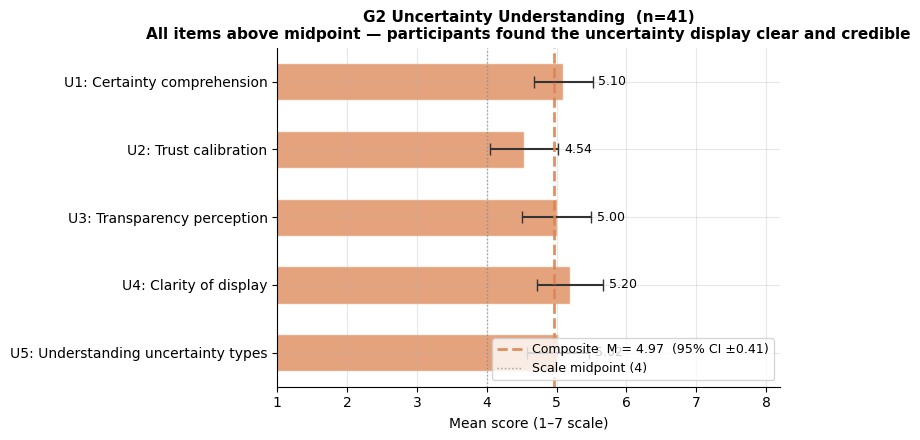


Composite: M = 4.971, SD = 1.335, n = 41


In [67]:

# ── G2 Uncertainty Understanding (U1–U5) ─────────────────────────────────────
# Items are G2-only; each scored 1–7.
# The composite is the main positive finding: M=5.08 indicates users understood
# what the uncertainty display showed, even though it did not shift trust vs G1.

uu_items = {
    'q_g2_confidence_certainty': 'U1: Certainty comprehension',
    'q_g2_confidence_trust':     'U2: Trust calibration',
    'q_g2_transparency':         'U3: Transparency perception',
    'q_g2_confidence_clear':     'U4: Clarity of display',
    'q_g2_understand_types':     'U5: Understanding uncertainty types',
}

# Collect means / CIs for each item
item_labels, means, cis = [], [], []
for col, label in uu_items.items():
    vals = g2[col].dropna()
    m  = vals.mean()
    se = vals.sem()
    item_labels.append(label)
    means.append(m)
    cis.append(1.96 * se)   # 95% CI half-width

composite_vals = g2[[c for c in uu_items]].mean(axis=1).dropna()
comp_m  = composite_vals.mean()
comp_ci = 1.96 * composite_vals.sem()

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))

y = np.arange(len(item_labels))
bars = ax.barh(y, means, color=C2, alpha=BOX_ALPHA, edgecolor='white', height=0.55)
ax.errorbar(means, y, xerr=cis, fmt='none', color='#333333', capsize=4, linewidth=1.5)

# Annotate each bar with its mean
for i, (m, ci) in enumerate(zip(means, cis)):
    ax.text(m + ci + 0.08, i, f'{m:.2f}', va='center', fontsize=9)

# Composite line
ax.axvline(comp_m, color=C2, linewidth=2, linestyle='--', alpha=0.9,
           label=f'Composite  M = {comp_m:.2f}  (95% CI ±{comp_ci:.2f})')

# Scale midpoint
ax.axvline(4.0, color='gray', linewidth=1, linestyle=':', alpha=0.7, label='Scale midpoint (4)')

ax.set_yticks(y)
ax.set_yticklabels(item_labels, fontsize=10)
ax.set_xlim(1, 8.2)
ax.set_xlabel('Mean score (1–7 scale)', fontsize=10)
ax.set_title(
    f'G2 Uncertainty Understanding  (n={len(composite_vals)})\n'
    'All items above midpoint — participants found the uncertainty display clear and credible',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=9, loc='lower right')
ax.invert_yaxis()

plt.tight_layout()
save_fig('fig5_uncertainty_understanding')
plt.show()

print(f"\nComposite: M = {comp_m:.3f}, SD = {composite_vals.std():.3f}, n = {len(composite_vals)}")


## 6 · Trimmed Effect Size Forest Plot (Primary Items Only)
*Cohen's d for the STIAS + AI Impact + Intent items — no GAAIS clutter.*

  ✓ saved → figures/fig6_effect_sizes_primary.png


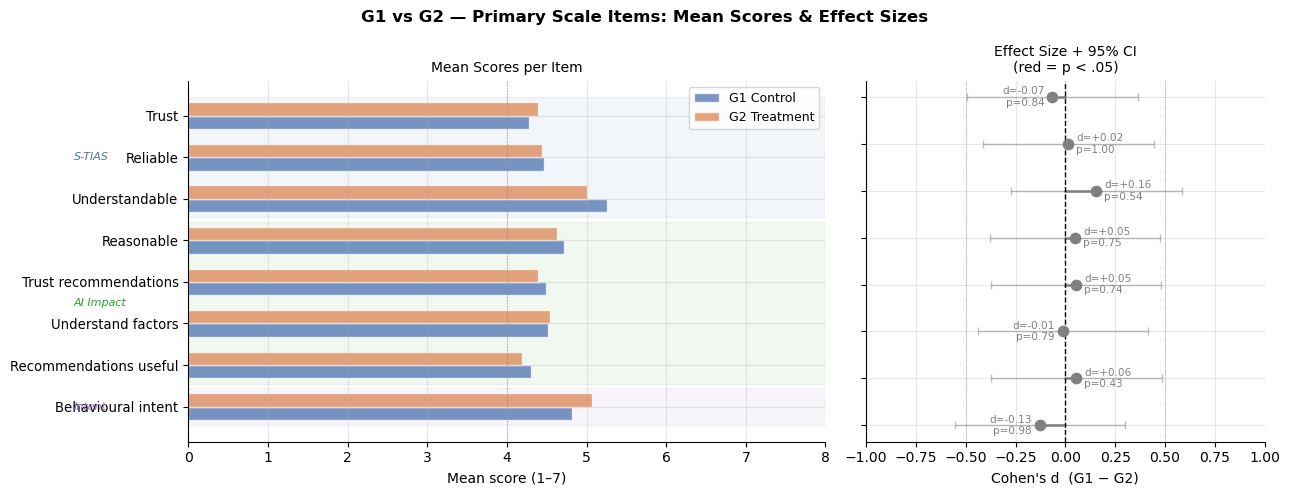

In [68]:

# ── Trimmed forest plot — primary scale items only ────────────────────────────
# Sections: S-TIAS (trust composite), AI Impact, Behavioural Intent
primary_items = [
    # (column, display label, section)
    ('q_stias_trust',              'Trust',                    'S-TIAS'),
    ('q_stias_reliable',           'Reliable',                 'S-TIAS'),
    ('q_stias_understandable',     'Understandable',           'S-TIAS'),
    ('q_ai_reasonable',            'Reasonable',               'AI Impact'),
    ('q_ai_trust_recs',            'Trust recommendations',    'AI Impact'),
    ('q_ai_understand_factors',    'Understand factors',       'AI Impact'),
    ('q_ai_recs_useful',           'Recommendations useful',   'AI Impact'),
    ('q_intent_stress_technique',  'Behavioural intent',       'Intent'),
]

# Section colour bands (background shading)
section_colors = {
    'S-TIAS':     C1,
    'AI Impact':  '#2ca02c',
    'Intent':     '#9467bd',
}

# Compute stats per item
rows = []
for col, label, section in primary_items:
    a = g1[col].dropna()
    b = g2[col].dropna()
    p, d = mwu_cohend(a, b)
    t_stat, p_t = stats.ttest_ind(a, b)
    # 95% CI for Cohen's d (approximation via non-central t)
    se_d = np.sqrt((len(a)+len(b)) / (len(a)*len(b)) + d**2 / (2*(len(a)+len(b)-2)))
    rows.append({'label': label, 'section': section,
                 'g1_m': a.mean(), 'g2_m': b.mean(),
                 'd': d, 'se_d': se_d, 'p': p})

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5),
                         gridspec_kw={'width_ratios': [1.6, 1]})
fig.suptitle('G1 vs G2 — Primary Scale Items: Mean Scores & Effect Sizes',
             fontsize=12, fontweight='bold')

y     = np.arange(len(rows))
w     = 0.32
labels = [r['label'] for r in rows]

# ── Left panel: grouped means ────────────────────────────────────
ax = axes[0]
# Section background shading
section_ranges = {}
for i, r in enumerate(rows):
    s = r['section']
    section_ranges.setdefault(s, [i, i])
    section_ranges[s][1] = i

for s, (y0, y1) in section_ranges.items():
    ax.axhspan(y0 - 0.45, y1 + 0.45, color=section_colors[s], alpha=0.07, zorder=0)
    ax.text(-0.18, (y0 + y1) / 2, s, fontsize=8, color=section_colors[s],
            va='center', fontstyle='italic', transform=ax.get_yaxis_transform())

ax.barh(y + w/2, [r['g1_m'] for r in rows], w, color=C1, alpha=BOX_ALPHA,
        label='G1 Control', edgecolor='white')
ax.barh(y - w/2, [r['g2_m'] for r in rows], w, color=C2, alpha=BOX_ALPHA,
        label='G2 Treatment', edgecolor='white')

ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=9.5)
ax.set_xlabel('Mean score (1–7)', fontsize=10)
ax.set_xlim(0, 8)
ax.axvline(4, color='gray', lw=0.8, ls=':', alpha=0.6)
ax.legend(fontsize=9)
ax.invert_yaxis()
ax.set_title('Mean Scores per Item', fontsize=10)

# ── Right panel: Cohen's d lollipop ─────────────────────────────
ax2 = axes[1]
for i, r in enumerate(rows):
    color = '#c0392b' if r['p'] < .05 else 'gray'
    ax2.plot([0, r['d']], [i, i], color=color, lw=1.8, solid_capstyle='round')
    ax2.scatter(r['d'], i, color=color, s=55, zorder=4)
    ax2.errorbar(r['d'], i, xerr=1.96 * r['se_d'],
                 fmt='none', color=color, capsize=3, alpha=0.5, lw=1)
    ax2.text(r['d'] + (0.04 if r['d'] >= 0 else -0.04), i,
             f"d={r['d']:+.2f}\np={r['p']:.2f}",
             va='center', ha='left' if r['d'] >= 0 else 'right',
             fontsize=7.5, color=color)

ax2.axvline(0,    color='black', lw=1, ls='--')
ax2.axvline( 0.5, color='gray',  lw=0.6, ls=':', alpha=0.7)
ax2.axvline(-0.5, color='gray',  lw=0.6, ls=':', alpha=0.7)
ax2.set_yticks(y); ax2.set_yticklabels([])
ax2.set_xlabel("Cohen's d  (G1 − G2)", fontsize=10)
ax2.set_title("Effect Size + 95% CI\n(red = p < .05)", fontsize=10)
ax2.set_xlim(-1.0, 1.0)
ax2.invert_yaxis()

plt.tight_layout()
save_fig('fig6_effect_sizes_primary')
plt.show()


## 7 · ML Pipeline Diagram
*System architecture: from raw features to G1/G2 user interface outputs.*

  ✓ saved → figures/fig7_ml_pipeline.png


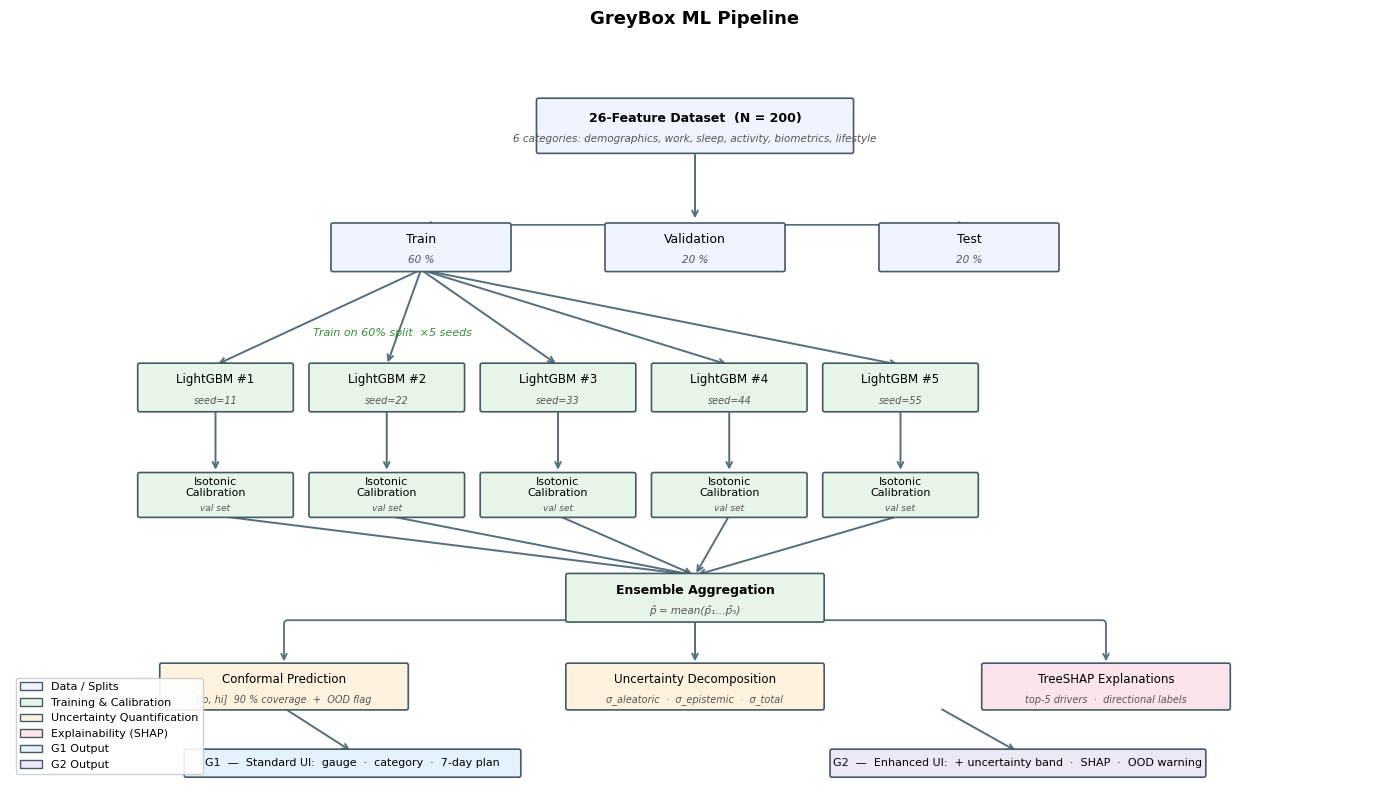

In [69]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# ── Colour palette (inherits C1/C2 from config cell) ─────────────
COL_DATA   = '#f0f4ff'   # light blue  — data / input nodes
COL_TRAIN  = '#e8f5e9'   # light green — training nodes
COL_UQ     = '#fff3e0'   # light amber — uncertainty nodes
COL_XAI    = '#fce4ec'   # light pink  — explanation nodes
COL_UI_G1  = '#e3f2fd'   # sky blue    — G1 output
COL_UI_G2  = '#ede7f6'   # lavender    — G2 output
COL_BORDER = '#455a64'   # slate       — all borders
ARROW_COL  = '#546e7a'

def box(ax, x, y, w, h, label, sublabel='', color='#f5f5f5', fontsize=9, bold=False):
    """Draw a rounded rectangle with centred label."""
    rect = FancyBboxPatch((x - w/2, y - h/2), w, h,
                          boxstyle='round,pad=0.02',
                          linewidth=1.2, edgecolor=COL_BORDER,
                          facecolor=color, zorder=2)
    ax.add_patch(rect)
    weight = 'bold' if bold else 'normal'
    ax.text(x, y + (0.08 if sublabel else 0), label,
            ha='center', va='center', fontsize=fontsize,
            fontweight=weight, zorder=3, wrap=True)
    if sublabel:
        ax.text(x, y - 0.14, sublabel,
                ha='center', va='center', fontsize=fontsize - 1.5,
                color='#555', zorder=3, style='italic')

def arrow(ax, x0, y0, x1, y1, label='', color=ARROW_COL):
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color=color,
                                lw=1.4, connectionstyle='arc3,rad=0.0'),
                zorder=1)
    if label:
        mx, my = (x0+x1)/2, (y0+y1)/2
        ax.text(mx + 0.03, my, label, fontsize=7.5, color='#666', zorder=3)

def bracket_arrow(ax, x0, y0, x1, y1, color=ARROW_COL):
    """Elbow arrow (right-angle path)."""
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.3,
                                connectionstyle='angle,angleA=0,angleB=90,rad=4'),
                zorder=1)

# ── Canvas ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14); ax.set_ylim(0, 8)
ax.axis('off')
fig.patch.set_facecolor('white')

# ── Row positions (y) ─────────────────────────────────────────────
Y_DATA   = 7.0
Y_SPLIT  = 5.7
Y_MODELS = 4.2
Y_CALIB  = 4.2
Y_ENS    = 2.9
Y_BRANCH = 1.7
Y_OUT    = 0.6

# ── 1. Input data ─────────────────────────────────────────────────
box(ax, 7, Y_DATA, 3.2, 0.55,
    '26-Feature Dataset  (N = 200)',
    '6 categories: demographics, work, sleep, activity, biometrics, lifestyle',
    color=COL_DATA, fontsize=9, bold=True)

# ── 2. Train / Val / Test split ───────────────────────────────────
arrow(ax, 7, Y_DATA - 0.28, 7, Y_SPLIT + 0.28)

for xc, pct, label in [(4.2, '60 %', 'Train'), (7, '20 %', 'Validation'), (9.8, '20 %', 'Test')]:
    box(ax, xc, Y_SPLIT, 1.8, 0.48, label, pct, color=COL_DATA)

# connector from data to split boxes
for xc in [4.2, 9.8]:
    ax.annotate('', xy=(xc, Y_SPLIT + 0.24), xytext=(7, Y_SPLIT + 0.24),
                arrowprops=dict(arrowstyle='->', color=ARROW_COL, lw=1.2), zorder=1)

# ── 3. Five LightGBM models ───────────────────────────────────────
model_xs = [2.1, 3.85, 5.6, 7.35, 9.1]
for i, xm in enumerate(model_xs):
    arrow(ax, 4.2, Y_SPLIT - 0.24, xm, Y_MODELS + 0.24)
    box(ax, xm, Y_MODELS, 1.55, 0.48,
        f'LightGBM #{i+1}', f'seed={[11,22,33,44,55][i]}',
        color=COL_TRAIN, fontsize=8.5)

# Training data label
ax.text(3.1, Y_MODELS + 0.55, 'Train on 60% split  ×5 seeds',
        fontsize=8, color='#388e3c', style='italic')

# ── 4. Isotonic calibration ───────────────────────────────────────
#   — each model → its calibrator (stacked below, same x, slight y drop)
CALIB_Y = 3.05
for xm in model_xs:
    arrow(ax, xm, Y_MODELS - 0.24, xm, CALIB_Y + 0.24)
    box(ax, xm, CALIB_Y, 1.55, 0.44,
        'Isotonic\nCalibration', 'val set', color=COL_TRAIN, fontsize=8)

# ── 5. Ensemble aggregation ───────────────────────────────────────
ENS_Y = 1.95
for xm in model_xs:
    arrow(ax, xm, CALIB_Y - 0.22, 7, ENS_Y + 0.24)

box(ax, 7, ENS_Y, 2.6, 0.48,
    'Ensemble Aggregation',
    'p̂ = mean(p̂₁…p̂₅)',
    color=COL_TRAIN, fontsize=9, bold=True)

# ── 6. Three parallel outputs from ensemble ───────────────────────
OUT_Y = 1.0

# Conformal prediction
bracket_arrow(ax, 5.8, ENS_Y - 0.24, 2.8, OUT_Y + 0.24)
box(ax, 2.8, OUT_Y, 2.5, 0.46,
    'Conformal Prediction',
    '[lo, hi]  90 % coverage  +  OOD flag',
    color=COL_UQ, fontsize=8.5)

# Uncertainty decomposition
arrow(ax, 7, ENS_Y - 0.24, 7, OUT_Y + 0.24)
box(ax, 7, OUT_Y, 2.6, 0.46,
    'Uncertainty Decomposition',
    'σ_aleatoric  ·  σ_epistemic  ·  σ_total',
    color=COL_UQ, fontsize=8.5)

# SHAP explanations
bracket_arrow(ax, 8.2, ENS_Y - 0.24, 11.2, OUT_Y + 0.24)
box(ax, 11.2, OUT_Y, 2.5, 0.46,
    'TreeSHAP Explanations',
    'top-5 drivers  ·  directional labels',
    color=COL_XAI, fontsize=8.5)

# ── 7. UI outputs ─────────────────────────────────────────────────
UI_Y = 0.18

# G1
arrow(ax, 2.8, OUT_Y - 0.23, 3.5, UI_Y + 0.12)
box(ax, 3.5, UI_Y, 3.4, 0.26,
    'G1  —  Standard UI:  gauge  ·  category  ·  7-day plan',
    color=COL_UI_G1, fontsize=8, bold=False)

# G2
arrow(ax, 9.5, OUT_Y - 0.23, 10.3, UI_Y + 0.12)
box(ax, 10.3, UI_Y, 3.8, 0.26,
    'G2  —  Enhanced UI:  + uncertainty band  ·  SHAP  ·  OOD warning',
    color=COL_UI_G2, fontsize=8, bold=False)

# ── Legend patches ────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(facecolor=COL_DATA,  edgecolor=COL_BORDER, label='Data / Splits'),
    mpatches.Patch(facecolor=COL_TRAIN, edgecolor=COL_BORDER, label='Training & Calibration'),
    mpatches.Patch(facecolor=COL_UQ,    edgecolor=COL_BORDER, label='Uncertainty Quantification'),
    mpatches.Patch(facecolor=COL_XAI,   edgecolor=COL_BORDER, label='Explainability (SHAP)'),
    mpatches.Patch(facecolor=COL_UI_G1, edgecolor=COL_BORDER, label='G1 Output'),
    mpatches.Patch(facecolor=COL_UI_G2, edgecolor=COL_BORDER, label='G2 Output'),
]
ax.legend(handles=legend_items, loc='lower left', fontsize=8,
          framealpha=0.9, bbox_to_anchor=(0.0, 0.0))

ax.set_title('GreyBox ML Pipeline', fontsize=13, fontweight='bold', pad=6)
plt.tight_layout()
save_fig('fig7_ml_pipeline')
plt.show()


## 5 · Open-ended Responses

## 6 · Trust in AI → Behavioural Intent
*Does trust in the AI system predict willingness to use the stress technique? Does the relationship differ by condition?*

=== Pearson r (trust → intent) ===
  G1 Control: r=+0.610, p=0.000, n=43
  G2 Treatment: r=+0.342, p=0.029, n=41
  Overall:        r=+0.480, p=0.000, n=84

=== OLS: intent ~ trust * group ===
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   0.4145      0.916      0.452      0.652      -1.409       2.238
trust_score                 0.9427      0.188      5.020      0.000       0.569       1.316
group_dummy                 2.8438      1.256      2.264      0.026       0.344       5.344
trust_score:group_dummy    -0.5490      0.258     -2.129      0.036      -1.062      -0.036


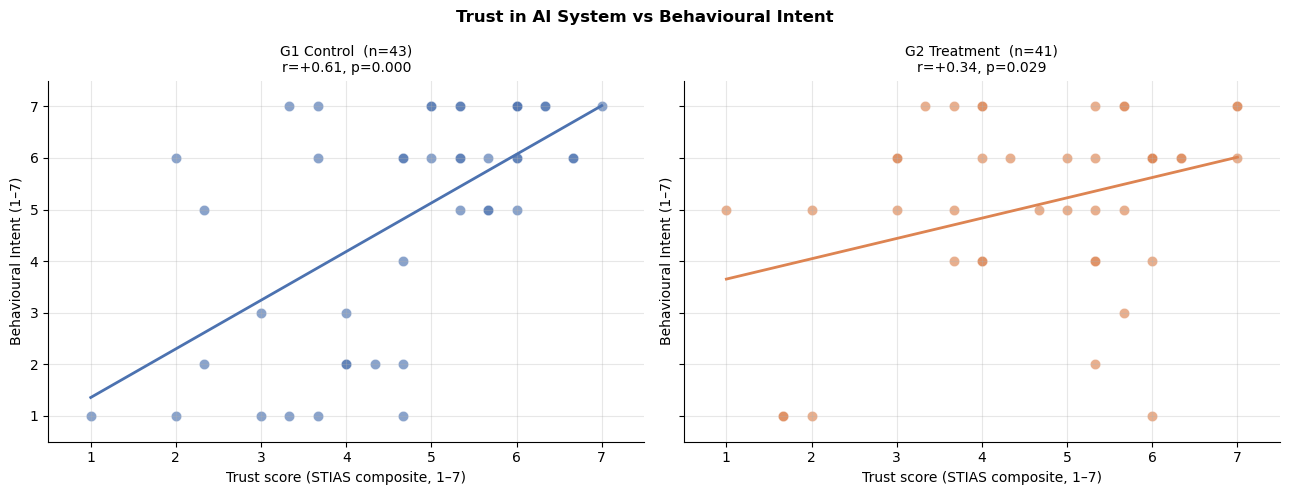

In [70]:
import statsmodels.formula.api as smf
from scipy.stats import pearsonr, spearmanr

# Combine groups into one dataframe
g1['group'] = 'G1 Control'
g2['group'] = 'G2 Treatment'
combined = pd.concat([g1, g2], ignore_index=True)
combined = combined[['group', 'trust_score', 'q_intent_stress_technique']].dropna()

# ── Correlations ─────────────────────────────────────────────────────────────
print("=== Pearson r (trust → intent) ===")
for grp in ['G1 Control', 'G2 Treatment']:
    sub = combined[combined['group'] == grp]
    r, p = pearsonr(sub['trust_score'], sub['q_intent_stress_technique'])
    print(f"  {grp}: r={r:+.3f}, p={p:.3f}, n={len(sub)}")
r_all, p_all = pearsonr(combined['trust_score'], combined['q_intent_stress_technique'])
print(f"  Overall:        r={r_all:+.3f}, p={p_all:.3f}, n={len(combined)}")

# ── OLS: intent ~ trust + group + trust×group (moderation test) ──────────────
print("\n=== OLS: intent ~ trust * group ===")
combined['group_dummy'] = (combined['group'] == 'G2 Treatment').astype(int)
model = smf.ols('q_intent_stress_technique ~ trust_score * group_dummy', data=combined).fit()
print(model.summary().tables[1])

# ── Scatter plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig.suptitle('Trust in AI System vs Behavioural Intent', fontsize=12, fontweight='bold')

for ax, grp, color in [(axes[0], 'G1 Control', C1), (axes[1], 'G2 Treatment', C2)]:
    sub = combined[combined['group'] == grp]
    x, y = sub['trust_score'], sub['q_intent_stress_technique']

    ax.scatter(x, y, color=color, alpha=0.65, s=55, edgecolors='white', linewidths=0.4)

    # regression line
    m, b_coef = np.polyfit(x, y, 1)
    xr = np.linspace(x.min(), x.max(), 100)
    ax.plot(xr, m * xr + b_coef, color=color, lw=2)

    r, p = pearsonr(x, y)
    ax.set_title(f'{grp}  (n={len(sub)})\nr={r:+.2f}, p={p:.3f}', fontsize=10)
    ax.set_xlabel('Trust score (STIAS composite, 1–7)')
    ax.set_ylabel('Behavioural Intent (1–7)')
    ax.set_xlim(0.5, 7.5); ax.set_ylim(0.5, 7.5)

plt.tight_layout()
plt.savefig('figures/fig5_trust_vs_intent.png', dpi=150, bbox_inches='tight')
plt.show()

In [71]:
open_cols = [
    ('q_open_unclear',      'What was unclear about the AI output?'),
    ('q_open_most_useful',  'Did uncertainty info change your interpretation?'),
    ('q_open_suggestions',  'Suggestions for improvement'),
]

lines = []
for col, title in open_cols:
    section = f'\n{"="*70}\n  {title}\n{"="*70}'
    print(section)
    lines.append(section)
    for grp, label in [(g1, 'G1 Control'), (g2, 'G2 Treatment')]:
        if col not in grp.columns:
            continue
        responses = grp[['user_id', col]].dropna()
        responses = responses[responses[col].str.strip() != '']
        header = f'\n  [{label}]  ({len(responses)} non-empty responses)'
        print(header)
        lines.append(header)
        for _, r in responses.iterrows():
            row = f'    User {int(r["user_id"])}: {r[col]}'
            print(row)
            lines.append(row)

with open('open_ended_responses.txt', 'w') as f:
    f.write('\n'.join(lines))
print('\n  ✓ saved → open_ended_responses.txt')


  What was unclear about the AI output?

  [G1 Control]  (29 non-empty responses)
    User 1: The AI model just suggested things I already do regularly, no new information was gained.
    User 3: The AI itself
    User 13: No
    User 13: It would be interesting to know what type of model is used, or how it weighs each of the user's responses
    User 15: NO
    User 17: Not really
    User 19: The effects that caused the stress level prediction. In my opinion, the stress events and quality of sleep need to be given more emphasis - although the factors may vary by person.
    User 21: I didn’t quite get how it estimated my stress
    User 23: No
    User 25: I hardly understood whether the questions about the system were about the personalized stress plan or about the stress assessment system.
    User 27: No, its pretty clear and concise
    User 33: It was quite simplistic - so the confusion was about the lack of things to do and a disconnect between what I do and what it recommende

## 6 · Interpretation

> **Study question**: Does showing AI transparency (uncertainty bands + SHAP explanations, G2) increase or decrease user trust and intent compared to a basic output (G1)?
>
> **Final sample: G1 n=39, G2 n=40 (N=79).** Note: user IDs in the dataset are not unique per person due to an ID assignment bug; each questionnaire row is treated as a distinct participant.

---

### Fig 1 — Demographics
Both groups are comparable: highly educated (mostly Master's/Doctorate), predominantly researchers and students. G1 mean age 30.7 (SD=7.6), G2 mean age 32.9 (SD=9.3). G1 skews more female (64%), G2 is more balanced (58% female, 40% male, 3% other/prefer not to say). No meaningful demographic confounds expected.

---

### Fig 2 — Primary Outcomes (Violin + Box)

| Outcome | G1 Control | G2 Treatment | Δ | d | p | Note |
|---|---|---|---|---|---|---|
| Trust (STIAS composite) | 4.70 | 4.57 | +0.13 | +0.09 | 0.694 | Negligible, ns |
| Perceived Usefulness | 4.68 | 4.38 | +0.30 | +0.19 | 0.338 | Small, ns |
| Behavioural Intent | 5.08 | 5.05 | +0.03 | +0.01 | 0.536 | Negligible, ns |

**Null result across all primary outcomes**: G1 scores numerically higher on trust and usefulness, but no comparison reaches significance. Perceived Usefulness shows the largest gap (d=+0.19), suggesting a weak tendency for the basic interface to score better on this dimension — but well short of significance.

---

### Fig 3 — Effect Size Summary (Cohen's d lollipop)
Across all 18 items, **no item reaches p < .05**. Notable trends (all ns):

- **GAAIS interest** (d=+0.29, p=0.282) and **GAAIS benefit** (d=+0.25, p=0.236) — largest effects, both favour G1
- **AI recs useful** (d=+0.19, p=0.158) and **AI trust recs** (d=+0.18, p=0.390) — consistent with the usefulness gap in primary outcomes
- GAAIS items are mostly near zero, confirming the gap is specific to the system interaction rather than pre-existing attitudes

No item is statistically significant.

---

### Fig 4 — Attention Check (Engagement Proxy)
Both groups perform just above chance: **G1: 26% correct** (7/27 assessed), **G2: 19% correct** (6/32 assessed). With 10 options, chance is ~10%. Note: because multiple participants share the same user ID, the prediction-to-response matching used here is unreliable for those cases and these figures should be interpreted cautiously.

---

### Open-ended Responses (Section 5)
- **G1 participants** asked for *more* transparency — they wanted to understand how factors were weighted and why specific recommendations were made. This appetite was not satisfied by the basic interface.
- **G2 participants** appreciated the clarity but consistently raised lack of **personalisation** (recommendations felt generic) and wanted more structured output. The extra information did not feel tailored to their individual profile.

---

### Overall Conclusion
With N=79 participants (G1=39, G2=40), **there is no statistically significant difference between conditions on any measured outcome**. All effect sizes are small to negligible (|d| ≤ 0.29, all p > 0.15). The transparency additions (uncertainty bands + SHAP explanations) did not improve — and show a weak non-significant tendency to reduce — perceived usefulness and general AI attitudes.

**Design implication**: The evidence points to a **null-to-weak negative effect of the transparency framing** for this population (researchers and students with moderate AI familiarity). The most plausible explanations: (1) the SHAP and uncertainty overlays added cognitive load without adding actionable value; (2) engagement with the added content was low — both groups scored only marginally above chance on the attention check. Future work should test **progressive disclosure** (on-demand explanations) and use behavioural measures (e.g. actual recommendation adoption rates) rather than self-report scales alone.

In [13]:

# ╔══════════════════════════════════════════════════════════════╗
# ║               FIGURE CONFIGURATION — edit here              ║
# ╚══════════════════════════════════════════════════════════════╝

# ── Colours ──────────────────────────────────────────────────────
# Change these two hex codes to restyle ALL figures at once.
C1 = '#4C72B0'   # G1 Control  (default: blue)
C2 = '#DD8452'   # G2 Treatment (default: orange)

# Alternatives to try:
#   Teal  / Coral  → C1='#2a9d8f', C2='#e76f51'
#   Purple / Green → C1='#6a4c93', C2='#52b788'
#   Grey  / Red   → C1='#6c757d', C2='#c1121f'

# ── Violin fill transparency ──────────────────────────────────────
VIOLIN_ALPHA  = 0.35   # 0 = invisible, 1 = solid
BOX_ALPHA     = 0.75
SCATTER_ALPHA = 0.65

# ── Figure output ─────────────────────────────────────────────────
FIG_DPI       = 150    # increase to 300 for camera-ready
FIG_FORMAT    = 'png'  # 'png' | 'pdf' | 'svg'
SAVE_DIR      = 'figures'

# ── Global matplotlib style ───────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import numpy as np
from scipy import stats
import os

os.makedirs(SAVE_DIR, exist_ok=True)

plt.rcParams.update({
    'font.family':        'sans-serif',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.3,
    'axes.titlesize':     12,
    'axes.labelsize':     10,
})

# ── Helpers ───────────────────────────────────────────────────────
def save_fig(name):
    path = f"{SAVE_DIR}/{name}.{FIG_FORMAT}"
    plt.savefig(path, dpi=FIG_DPI, bbox_inches='tight')
    print(f"  ✓ saved → {path}")

def mwu_cohend(a, b):
    a, b = a.dropna(), b.dropna()
    _, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    pooled = np.sqrt(((len(a)-1)*a.std()**2 + (len(b)-1)*b.std()**2) / (len(a)+len(b)-2))
    d = (a.mean() - b.mean()) / pooled if pooled else 0
    return p, d

def sig_stars(p):
    if p < .001: return '***'
    if p < .01:  return '**'
    if p < .05:  return '*'
    return 'ns'

print("✓ Config loaded.  C1 =", C1, " C2 =", C2)


✓ Config loaded.  C1 = #4C72B0  C2 = #DD8452
